# 04 – Model Evaluation (FIXED for new feature set + baseline + Random Forest median)

**Purpose:** Evaluate the three trained models on the held‑out test set using the new 13‑feature pipeline.

**Metrics:**
- Median model (Random Forest): R², MAE, RMSE
- Quantile models (neural nets, τ=0.1 & τ=0.9): Prediction interval coverage (80%)
- Baseline (crop‑wise median): R², MAE, RMSE
- Visualisations: Scatter plot, residual distribution, coverage by crop

**Note:** Crop names are recovered from saved `test_crop_names.npy` (to avoid scaling/precision issues).

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Load test data
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')
y_train = np.load('../data/y_train.npy')   # for baseline fallback

# Log transform target (only used for quantile models)
y_test_log = np.log1p(y_test)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

print(f"Test set size: {len(X_test)}")
print(f"Test features shape: {X_test.shape}")

Test set size: 2929
Test features shape: (2929, 13)


In [3]:
# Neural net architecture for quantile models (lower and upper)
class YieldPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_test.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 13


In [4]:
# Load Random Forest median model
model_median = joblib.load('../backend/models/yield_model_median_rf.pkl')

# Load quantile neural nets (lower and upper)
model_lower = YieldPredictor(input_dim).to(device)
model_lower.load_state_dict(torch.load('../backend/models/yield_model_lower.pt', map_location=device))
model_lower.eval()

model_upper = YieldPredictor(input_dim).to(device)
model_upper.load_state_dict(torch.load('../backend/models/yield_model_upper.pt', map_location=device))
model_upper.eval()

print("All three models loaded (Random Forest median + quantile NNs).")

All three models loaded (Random Forest median + quantile NNs).


In [5]:
# Median predictions (Random Forest)
pred_median = model_median.predict(X_test)

# Quantile predictions (neural nets)
with torch.no_grad():
    pred_lower_log = model_lower(X_test_t).cpu().numpy().flatten()
    pred_upper_log = model_upper(X_test_t).cpu().numpy().flatten()

pred_lower = np.expm1(pred_lower_log)
pred_upper = np.expm1(pred_upper_log)

print("Predictions generated.")

Predictions generated.


### Baseline: Crop‑wise median prediction

In [6]:
# Load crop medians and test crop names
crop_medians = joblib.load('../backend/models/crop_medians.pkl')
test_crop_names = np.load('../data/test_crop_names.npy', allow_pickle=True)

# Baseline prediction: crop‑wise median (fallback to global median if crop missing)
overall_median = np.median(y_train)
baseline_pred = np.array([crop_medians.get(crop, overall_median) for crop in test_crop_names])

# Evaluate baseline
r2_baseline = r2_score(y_test, baseline_pred)
mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("=" * 50)
print("BASELINE (crop‑wise median) Performance")
print("=" * 50)
print(f"R²: {r2_baseline:.4f}")
print(f"MAE: {mae_baseline:.2f} tons/ha")
print(f"RMSE: {rmse_baseline:.2f} tons/ha")

BASELINE (crop‑wise median) Performance
R²: 0.6544
MAE: 2.19 tons/ha
RMSE: 6.92 tons/ha


### Median Model (Random Forest) Evaluation

In [7]:
r2 = r2_score(y_test, pred_median)
mae = mean_absolute_error(y_test, pred_median)
rmse = np.sqrt(mean_squared_error(y_test, pred_median))

print("=" * 50)
print("Median Model (Random Forest) Performance")
print("=" * 50)
print(f"R² score: {r2:.4f}")
print(f"MAE: {mae:.2f} tons/ha")
print(f"RMSE: {rmse:.2f} tons/ha")

Median Model (Random Forest) Performance
R² score: 0.8021
MAE: 1.17 tons/ha
RMSE: 5.24 tons/ha


### Quantile Models (τ=0.1, τ=0.9) – 80% Prediction Interval

In [8]:
coverage_80 = np.mean((pred_lower <= y_test) & (y_test <= pred_upper))
width_80 = (pred_upper - pred_lower).mean()

print("=" * 50)
print("Quantile Models (τ=0.1, τ=0.9) – 80% Prediction Interval")
print("=" * 50)
print(f"Actual coverage: {coverage_80*100:.1f}% (target 80%)")
print(f"Average interval width: {width_80:.2f} tons/ha")
print(f"Upper bound too low? {np.mean(pred_upper < y_test)*100:.1f}%")
print(f"Lower bound too high? {np.mean(pred_lower > y_test)*100:.1f}%")

Quantile Models (τ=0.1, τ=0.9) – 80% Prediction Interval
Actual coverage: 85.9% (target 80%)
Average interval width: 10.24 tons/ha
Upper bound too low? 8.4%
Lower bound too high? 5.7%


### Visualisations

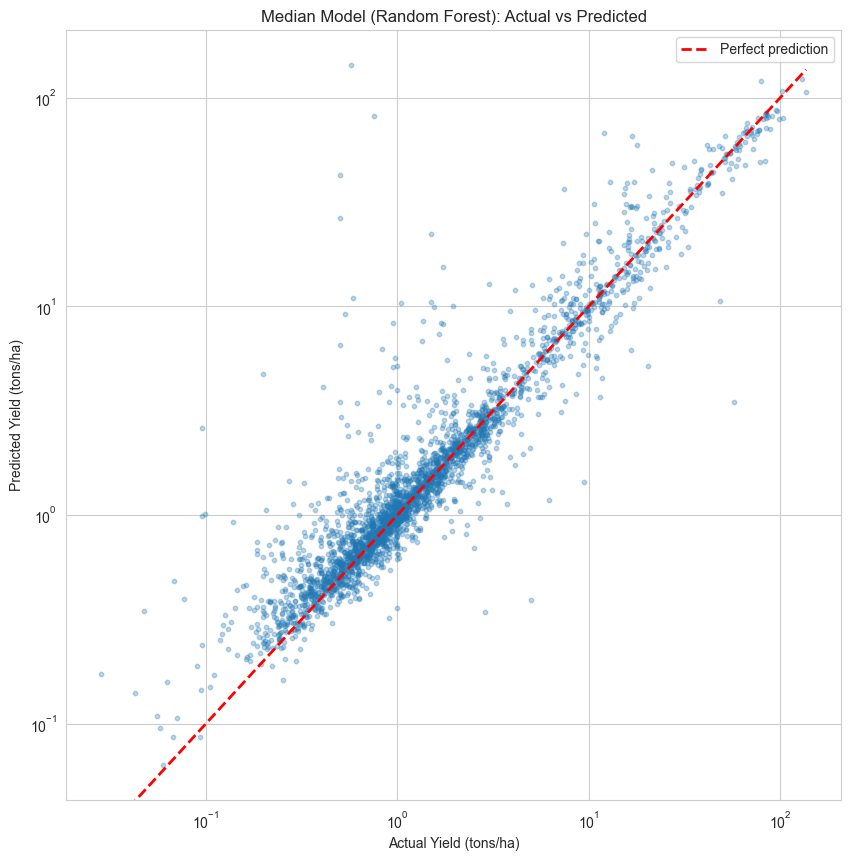

In [9]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, pred_median, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Yield (tons/ha)')
plt.ylabel('Predicted Yield (tons/ha)')
plt.title('Median Model (Random Forest): Actual vs Predicted')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

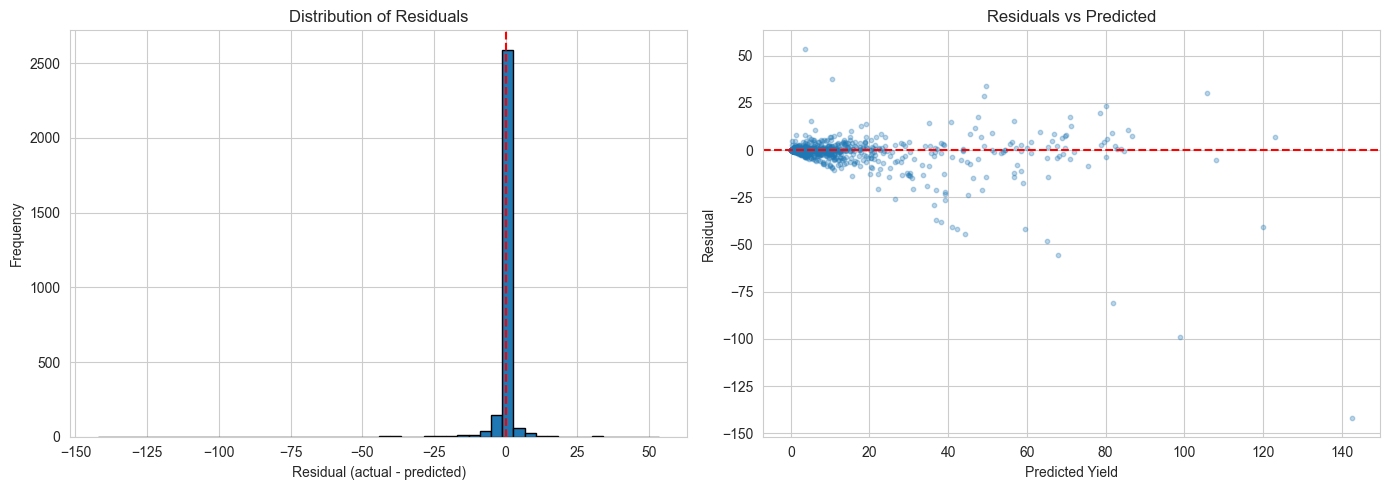

In [10]:
residuals = y_test - pred_median

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')
axes[0].axvline(x=0, color='r', linestyle='--')

axes[1].scatter(pred_median, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Yield')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

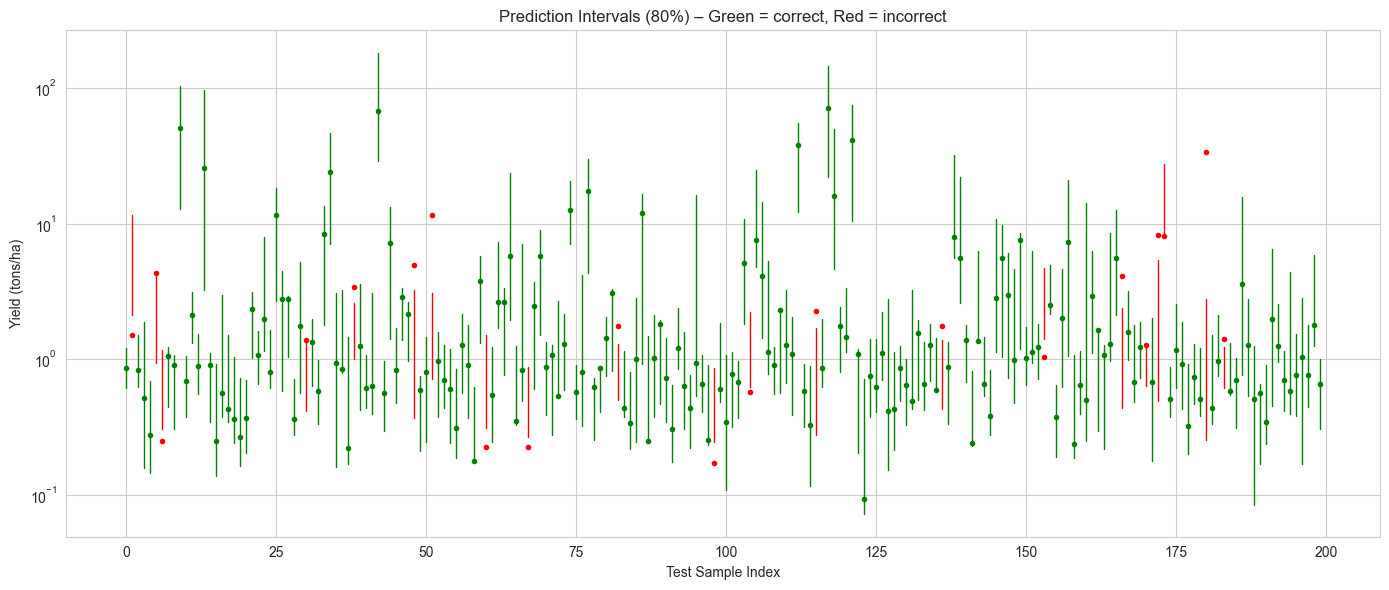

In [11]:
sample_idx = np.random.choice(len(y_test), 200, replace=False)
sample_idx.sort()

plt.figure(figsize=(14, 6))
for i, idx in enumerate(sample_idx):
    y_true = y_test[idx]
    lower = pred_lower[idx]
    upper = pred_upper[idx]
    color = 'green' if lower <= y_true <= upper else 'red'
    plt.plot([i, i], [lower, upper], color=color, linewidth=1)
    plt.plot(i, y_true, 'o', color=color, markersize=3)

plt.xlabel('Test Sample Index')
plt.ylabel('Yield (tons/ha)')
plt.title('Prediction Intervals (80%) – Green = correct, Red = incorrect')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [12]:
print("=" * 60)
print("EVALUATION SUMMARY & RECOMMENDATIONS")
print("=" * 60)

if coverage_80 >= 0.75:
    print("✓ 80% prediction interval coverage is acceptable (≥75%).")
else:
    print("✗ 80% prediction interval coverage is below 75%. Consider wider quantiles (τ=0.05,0.95).")

if r2 > 0.5:
    print("✓ Median model R² is acceptable (>0.5).")
else:
    print("✗ Median model R² is low (<0.5). Consider more features or per‑crop models.")

print("\nFor the hackathon demo:")
print("- Use the Random Forest model for point estimate.")
print("- Use the quantile range as the primary output (confidence interval).")
print("- Emphasise the automatic data fetching (GEE rainfall + pH) and the interactive map.")

EVALUATION SUMMARY & RECOMMENDATIONS
✓ 80% prediction interval coverage is acceptable (≥75%).
✓ Median model R² is acceptable (>0.5).

For the hackathon demo:
- Use the Random Forest model for point estimate.
- Use the quantile range as the primary output (confidence interval).
- Emphasise the automatic data fetching (GEE rainfall + pH) and the interactive map.
